## Corporación Favorita Grocery Sales Forecasting-Datensatz

Ablaufplan
Schritt 1: Fehlende Werte prüfen
Schritt 2: Ausreißer behandeln
Schritt 3: Fehlende Datumswerte mit Null-Umsatz auffüllen
Schritt 4: Feature Engineering – aus Datum nützliche Signale ableiten
Schritt 5: Zeitreihen visualisieren
Schritt 6: Einfluss von Feiertagen untersuchen
Schritt 7: Verderbliche Artikel analysieren

In [2]:
import pandas as pd
from scipy.optimize._trustregion_constr import minimize_trustregion_constr
from sklearn.metrics import mean_absolute_error

In [3]:
data=pd.read_csv('timeseries.csv')

In [4]:
data.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        452 non-null    str    
 1   unit_sales  452 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB


In [5]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)  # Set 'date' as the index
data.isnull().sum() #missing values?

unit_sales    0
dtype: int64

In [6]:
# Check if all days are vorhanden
date_range = pd.date_range(start=data.index.min(), end=data.index.max())
missing_dates = date_range.difference(data.index)
missing_dates

DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[us]', freq=None)

In [10]:
# 2 fehlen -> auffüllen mit den fehlenden Werten
data = data.reindex(date_range)
data['unit_sales'] = data['unit_sales'].ffill() #forward fill: füllt nan werte mit dem letzten verfügbaren eintrag

In [11]:
holidays = pd.read_csv('holidays.csv')
oil= pd.read_csv('oil.csv')
stores=pd.read_csv('stores.csv')

In [17]:
holidays.isnull().sum()

date           0
locale         0
locale_name    0
description    0
dtype: int64

In [16]:
holidays['locale_name'].unique()

<StringArray>
[                         'Manta',                       'Cotopaxi',
                         'Cuenca',                       'Libertad',
                       'Riobamba',                           'Puyo',
                       'Guaranda',                       'Imbabura',
                      'Latacunga',                        'Machala',
                  'Santo Domingo',                      'El Carmen',
                        'Cayambe',                     'Esmeraldas',
                        'Ecuador',                         'Ambato',
                         'Ibarra',                        'Quevedo',
 'Santo Domingo de los Tsachilas',                    'Santa Elena',
                          'Quito',                           'Loja',
                        'Salinas',                      'Guayaquil']
Length: 24, dtype: str

In [11]:
'''# bei holidays funktioniert das nicht, die sind und müssen unzusammenhängend sein...
holidays['date'] = pd.to_datetime(holidays['date'])
holidays.set_index('date', inplace=True)
date_range_h = pd.date_range(start=holidays.index.min(), end=holidays.index.max())
date_range_h.difference(holidays.index)
'''

"# bei holidays funktioniert das nicht, die sind und müssen unzusammenhängend sein...\nholidays['date'] = pd.to_datetime(holidays['date'])\nholidays.set_index('date', inplace=True)\ndate_range_h = pd.date_range(start=holidays.index.min(), end=holidays.index.max())\ndate_range_h.difference(holidays.index)\n"

In [23]:
stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   store_nbr  54 non-null     int64
 1   city       54 non-null     str  
 2   region     54 non-null     str  
dtypes: int64(1), str(2)
memory usage: 1.4 KB


In [26]:
stores['region'].unique()

<StringArray>
[                     'Pichincha', 'Santo Domingo de los Tsachilas',
                       'Cotopaxi',                     'Chimborazo',
                       'Imbabura',                        'Bolivar',
                        'Pastaza',                     'Tungurahua',
                         'Guayas',                    'Santa Elena',
                       'Los Rios',                          'Azuay',
                           'Loja',                         'El Oro',
                     'Esmeraldas',                         'Manabi']
Length: 16, dtype: str

In [12]:
oil.info()

<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   str    
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), str(1)
memory usage: 19.2 KB


In [18]:
oil['date'] = pd.to_datetime(oil['date'])
oil.set_index('date', inplace=True)
date_range_o = pd.date_range(start=oil.index.min(), end=oil.index.max())
date_range_o.difference(oil.index)

DatetimeIndex(['2013-01-05', '2013-01-06', '2013-01-12', '2013-01-13',
               '2013-01-19', '2013-01-20', '2013-01-26', '2013-01-27',
               '2013-02-02', '2013-02-03',
               ...
               '2017-07-29', '2017-07-30', '2017-08-05', '2017-08-06',
               '2017-08-12', '2017-08-13', '2017-08-19', '2017-08-20',
               '2017-08-26', '2017-08-27'],
              dtype='datetime64[us]', length=486, freq=None)

In [21]:
#immer die Wochenenden fehlen natürlich. Will aber keine Nan werte dort haben
oil_ = oil.reindex(date_range_o)
oil_['dcoilwtico'] = oil_['dcoilwtico'].ffill()

In [22]:
oil_

,dcoilwtico
2013-01-02,93.14
2013-01-03,92.97
2013-01-04,93.12
2013-01-05,93.12
2013-01-06,93.12
...,...
2014-03-27,101.25
2014-03-28,101.73
2014-03-29,101.73
2014-03-30,101.73


In [15]:
#%pip install DARTS

In [16]:
#import DARTS

ModuleNotFoundError: No module named 'DARTS'

In [ ]:
#%pip install seaborn

In [29]:
from darts import TimeSeries
series = TimeSeries.from_dataframe(data, value_cols='unit_sales')

In [28]:
import matplotlib.pyplot as plt

<Axes: xlabel='time'>

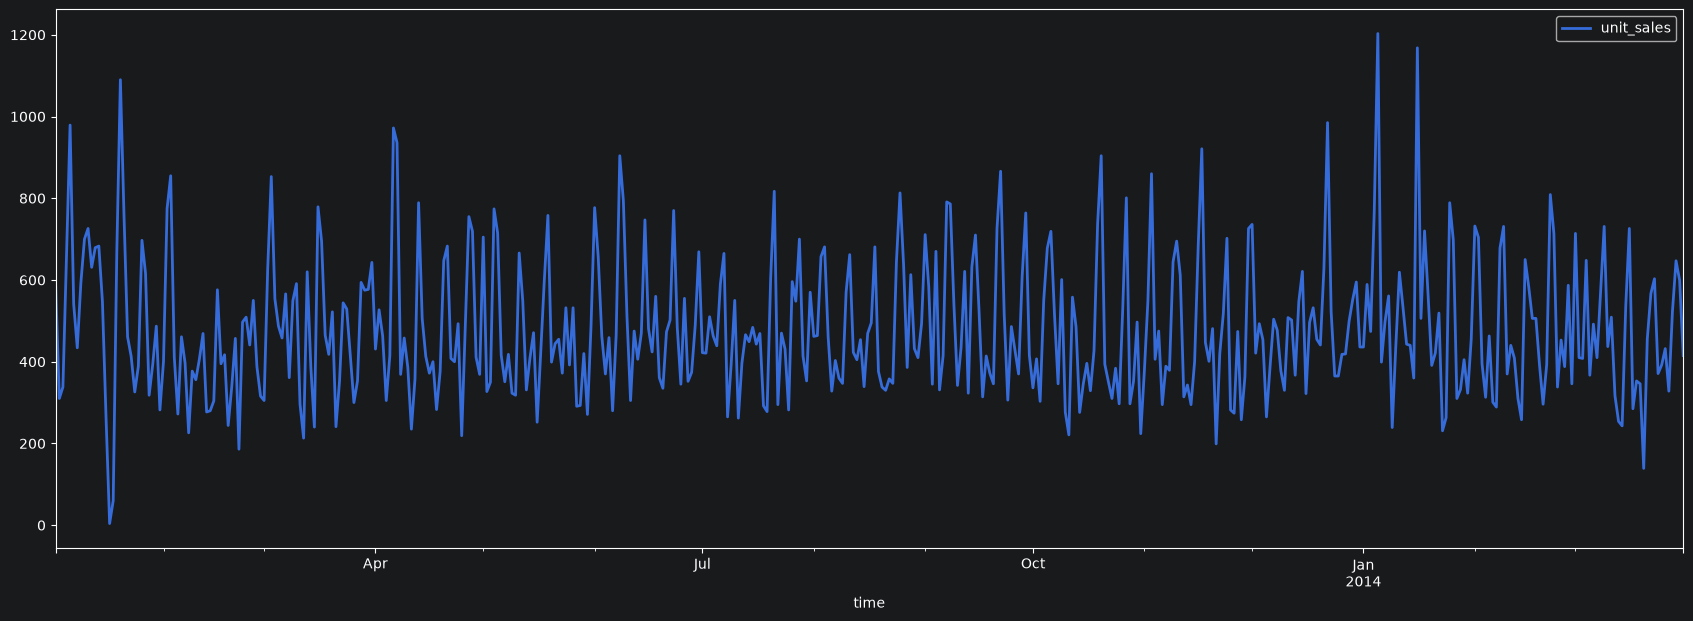

In [17]:
# Visualisiere die gefilterten Verkaufsdaten
plt.figure(figsize=(21, 7))  # Größe der Abbildung anpassen (Breite, Höhe)
series.plot()

In [33]:
# Daten aufteilen (nach 80% Training splitte, 20% Test)
#train, test = series.split_after(0.8)
#oder wenn ich an einem bestimmten Datum splitten will:
train = data[data.index<'2014-01-01']
test = data[data.index>='2014-01-01']

### für ARIMA / SARIMA

In [31]:
from darts.models import ARIMA

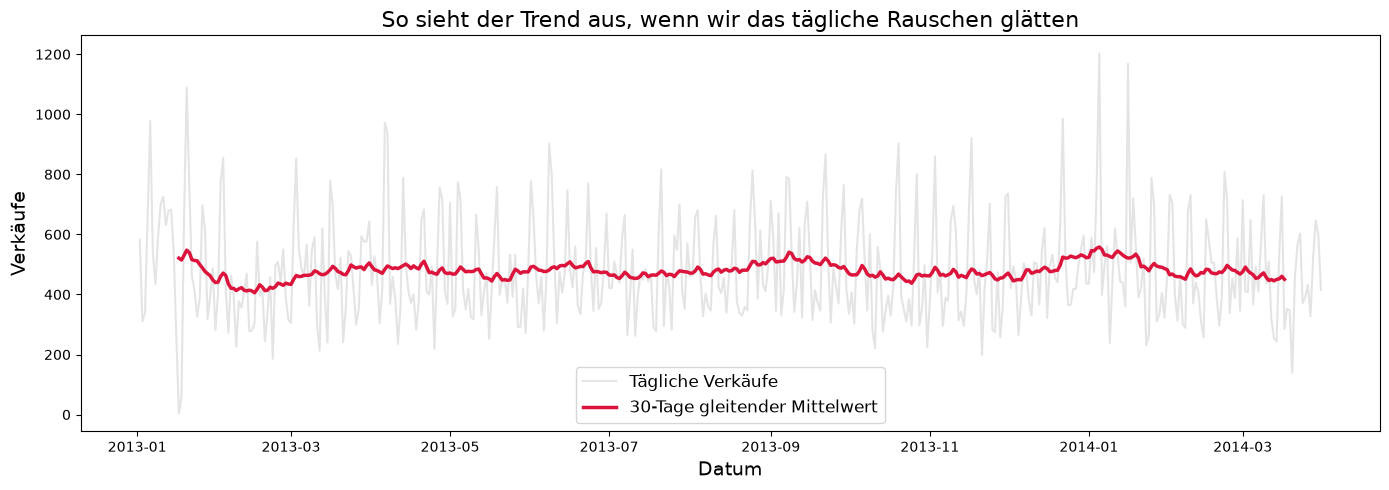

In [30]:
# Berechne gleitenden 30-Tage-Mittelwert zur Glättung
rolling_trend = data['unit_sales'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 5))
# Zeichne die täglichen Verkaufszahlen in hellgrau
plt.plot(data.index, data['unit_sales'],
         color='lightgray', alpha=0.6, label='Tägliche Verkäufe')

# Zeichne den gleitenden Mittelwert in kräftigem Rot
plt.plot(rolling_trend.index, rolling_trend.values,
         color='crimson', linewidth=2.5, label='30-Tage gleitender Mittelwert')

plt.title("So sieht der Trend aus, wenn wir das tägliche Rauschen glätten", fontsize=16)
plt.xlabel("Datum", fontsize=14)
plt.ylabel("Verkäufe", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [27]:
import numpy as np

#### Wert d für ARIMA: Differenzierung - entfernt möglichen Trend

In [29]:
#ADF Test für stationär. Nullhypothese ist nicht stationär, wenn p>0,05
from statsmodels.tsa.stattools import adfuller

# adfuller() funktioniert nicht direkt mit Darts TimeSeries –
# wir müssen die Werte extrahieren:
#arr = train.values().flatten()   # Bei univariater Serie in 1D umwandeln

# ADF-Test ausführen
result = adfuller(train) #sonst mit arr
print(result[1])
#print(f"ADF p-value: {p:.2e}")

0.0006123184685637161


In [33]:
''' Muss ich hier nicht machen weil p wert kleiner als 0,05
# Führe die erste Differenzierung durch – das ist unsere neue differenzierte Trainingsreihe
diff1 = np.diff(arr, 1)
# ADF-Test auf der differenzierten Serie
result = adfuller(diff1)
print("p-Wert der 1. Differenzierung:", result[1])
'''

p-Wert der 1. Differenzierung: 4.030957162375594e-12


d Wert für ARIMA ist 0, weil Daten stationär sind

#### Wert p für ARIMA
Wie viele vergangene Tage brauche ich zur Vorhersage?

In [30]:
from statsmodels.graphics.tsaplots import plot_pacf

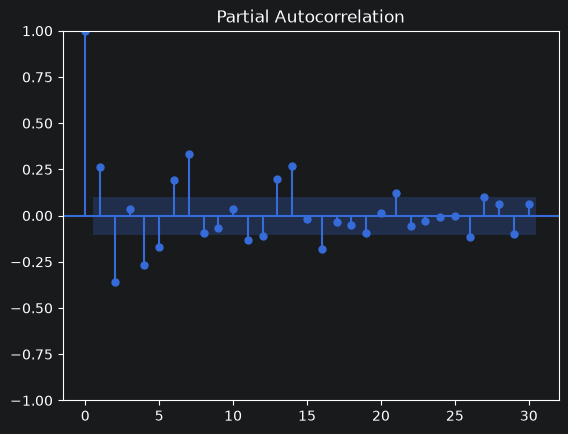

In [31]:
plot_pacf(train, lags=30) #30 Tage Vergangenheit angucken, mal sehen was passt
plt.show()

0 ist 1 wie immer, 2 könnte gut sein, weil 3 unter Konfidenzintervall liegt (95%), sonst 7 ausprobieren, könnte aber auch overfitten
=> p=2 / p=7

#### Parameter q: Wie viele vergangene Fehler beachten?

In [32]:
from statsmodels.graphics.tsaplots import plot_acf

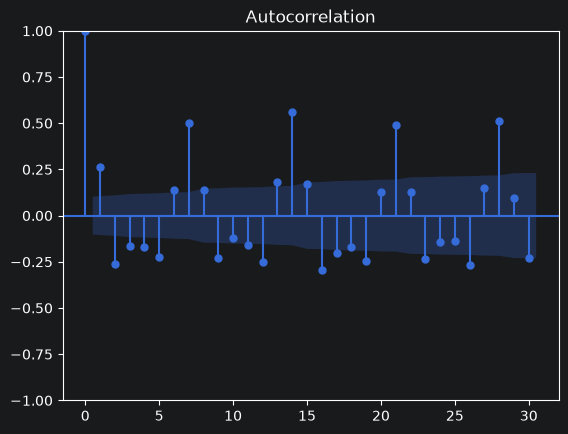

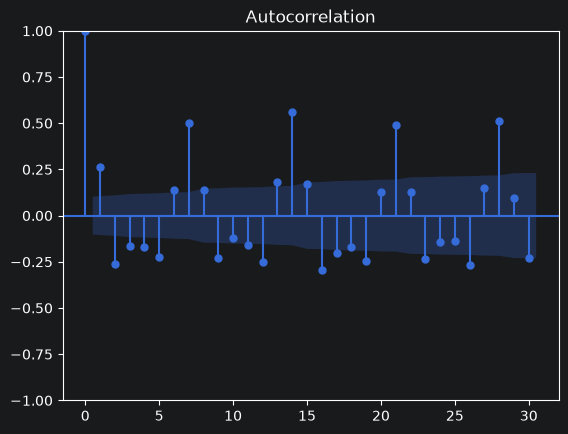

In [33]:
plot_acf(train, lags=30) # wieder 30 ausprobieren, sollte auf jeden Fall drunter liegen

Sieht seeehr stark nach saisonalität aus durch wiederkehrendes Muster (7 Tage Rythmus).. ARIMA ist also das falsche Modell, besser SARIMA verwenden. Trotzdem mal mit ARIMA austesten. mit q= 7 vielleicht, sonst auch mal 2 ausprobieren.

D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


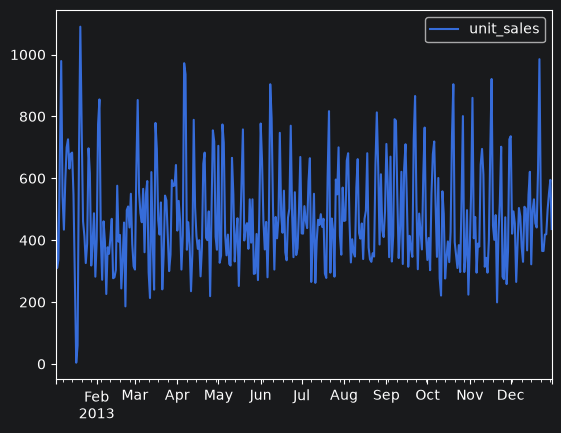

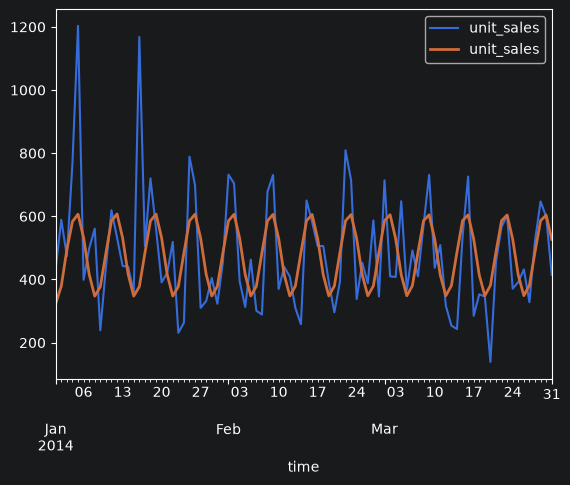

In [39]:
model_arima = ARIMA(p=2,d=0,q=7) #d=0, p=2/7, q=7/2
model_arima.fit(TimeSeries.from_dataframe(train, value_cols='unit_sales'))
forecast_arima=model_arima.predict(len(test))
train.plot()
test.plot()
forecast_arima.plot()
plt.show()

In [57]:
#Zur Validierung
from sklearn.metrics import mean_absolute_error
aic=model_arima.model.aic
mae = mean_absolute_error(test,forecast_arima.values().flatten())#test ist ein Df, die Vorhersage ein Timeseries object, daher so
print(aic, mae)

4593.0506421823875 114.4067444851239


D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


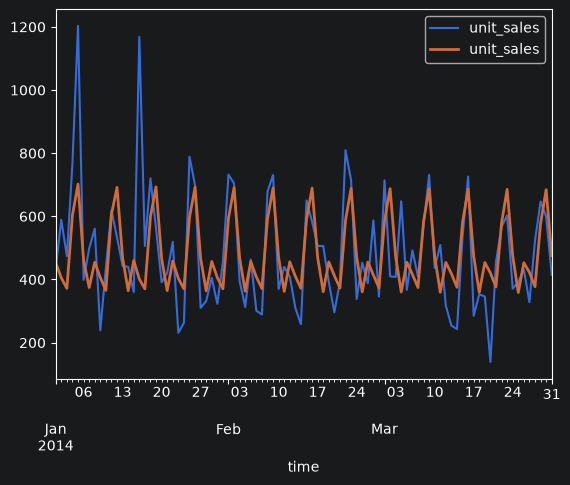

4519.93608762263 128.78221238336715


In [60]:
model_arima = ARIMA(p=7,d=0,q=7) #d=0, p=2/7, q=7/2
model_arima.fit(TimeSeries.from_dataframe(train, value_cols='unit_sales'))
forecast_arima_best=model_arima.predict(len(test))

test.plot()
forecast_arima_best.plot()
plt.show()

aic=model_arima.model.aic
mae = mean_absolute_error(test,forecast_arima_best.values().flatten())#test ist ein Df, die Vorhersage ein Timeseries object, daher so
print(aic, mae)

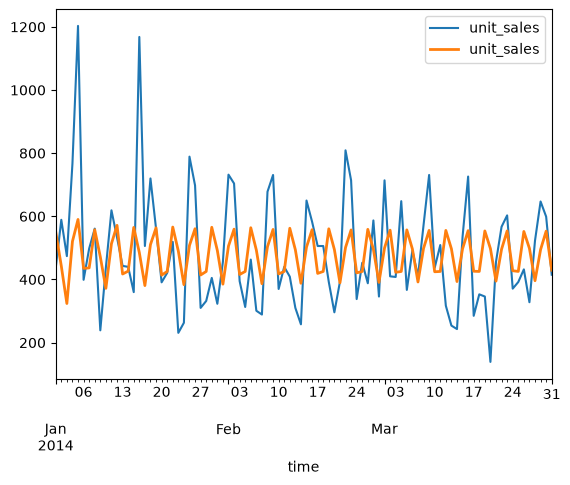

4571.313980971309 128.78221238336715


In [37]:
import warnings
warnings.filterwarnings("ignore")

model_arima = ARIMA(p=7,d=0,q=2) #d=0, p=2/7, q=7/2
model_arima.fit(TimeSeries.from_dataframe(train, value_cols='unit_sales'))
forecast_arima=model_arima.predict(len(test))

test.plot()
forecast_arima.plot()
plt.show()

aic=model_arima.model.aic
mae = mean_absolute_error(test,forecast_arima.values().flatten())#test ist ein Df, die Vorhersage ein Timeseries object, daher so
print(aic, mae)

ARIMA(p=7,d=0,q=7) hat die geringste aic &mae score, der ist es

ARIMA(p=7,d=0,q=7) hat den besten aic & mae score , die Parameter sind es

In [ ]:
'''
das oben mit
param_grid{'p':[2,7],'d':0, 'q':[2,7]}
grid_search= GridSearchCV(estimator=model, param_grid=param_grid, scoring=)
machen. nur geht das nur bei sklearn modellen, nicht mit arima...
'''

In [64]:
from sklearn.metrics import classification_report


,unit_sales
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0
2014-03-30,599.0


In [74]:
forecast_arima_best.values().flatten()
test['unit_sales'].values

array([ 436.,  589.,  474.,  767., 1203.,  399.,  498.,  561.,  239.,
        438.,  619.,  533.,  443.,  440.,  360., 1168.,  506.,  720.,
        561.,  391.,  421.,  519.,  231.,  263.,  789.,  698.,  310.,
        332.,  405.,  323.,  456.,  732.,  704.,  395.,  313.,  463.,
        301.,  289.,  678.,  731.,  370.,  440.,  409.,  310.,  258.,
        650.,  583.,  506.,  506.,  392.,  296.,  393.,  809.,  714.,
        338.,  453.,  388.,  587.,  346.,  714.,  410.,  408.,  648.,
        367.,  492.,  410.,  572.,  731.,  437.,  509.,  317.,  254.,
        243.,  535.,  726.,  285.,  353.,  346.,  139.,  456.,  567.,
        603.,  371.,  392.,  432.,  328.,  523.,  647.,  599.,  415.])

In [73]:
class_report_arima = classification_report(test['unit_sales'].values, forecast_arima_best.values().flatten() )
# Valueerror

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

## Modell SARIMA

In [ ]:
#Modelle vergleichen mit
#results = pd.concat ... guck auf seite über hyperparameter